# Tutorial 3: Halo mass functions and collapse thresholds

The halo mass function $\mathrm{d}n/\mathrm{d}M$ — the comoving number
density of dark matter halos per unit mass — is the backbone of any
semi-analytic model. Its ingredients are all objects from Tutorial 2 plus
two collapse-threshold classes:

* `criticalOverdensity` — the linearly-extrapolated collapse threshold
  $\delta_\mathrm{c}(t)$ from spherical-collapse theory
  ($\simeq 1.686$ for Einstein-de Sitter);
* `virialDensityContrast` — the mean density contrast $\Delta_\mathrm{vir}(t)$
  of a just-virialized halo ($\simeq 178$ for Einstein-de Sitter, higher in
  $\Lambda$CDM today).

We compare the Sheth & Tormen (1999) and Tinker et al. (2008) mass
functions and follow their evolution to high redshift.

In [1]:
import os, sys

# Locate the Galacticus library interface. Two supported layouts:
#  * a Galacticus source tree built with
#      make GALACTICUS_BUILD_OPTION=lib libgalacticus.so
#    (galacticus.py at the tree root, the library under galacticus/lib/);
#  * an unpacked binary distribution (the `galacticus/` folder from
#    libgalacticus.tar.bz2, with python/ and lib/ inside it).
# Set GALACTICUS_LIBRARY_PATH to the directory CONTAINING the `galacticus/`
# folder if the auto-detection below does not fit your setup.
root = os.environ.get('GALACTICUS_LIBRARY_PATH',
                      os.path.abspath(os.path.join(os.getcwd(), os.pardir)))
os.chdir(root)   # galacticus.py loads galacticus/lib/libgalacticus.so relative to here
for candidate in (root, os.path.join(root, 'galacticus', 'python')):
    if os.path.exists(os.path.join(candidate, 'galacticus.py')):
        sys.path.insert(0, candidate)
        break
else:
    raise RuntimeError(f"galacticus.py not found under {root} - build the library "
                       "(make GALACTICUS_BUILD_OPTION=lib libgalacticus.so) or set "
                       "GALACTICUS_LIBRARY_PATH")

import numpy as np
import matplotlib.pyplot as plt
import galacticus
print("Galacticus library interface loaded.")

Galacticus library interface loaded.


In [2]:
plt.rcParams.update({'figure.figsize': (7.0, 4.5), 'font.size': 11,
                     'axes.grid': True, 'grid.alpha': 0.3})

In [3]:
# Assemble the sigma(M) chain (see Tutorial 2 for a walk-through).
cosmologyParameters = galacticus.cosmologyParametersSimple(0.3, 0.045, 0.7, 2.78, 70.0)
cosmologyFunctions  = galacticus.cosmologyFunctionsMatterLambda(cosmologyParameters)
darkMatterParticle  = galacticus.darkMatterParticleCDM()
transferFunction    = galacticus.transferFunctionEisensteinHu1999(
    3.046, 0.0, darkMatterParticle, cosmologyParameters, cosmologyFunctions)
linearGrowth        = galacticus.linearGrowthCollisionlessMatter(cosmologyParameters, cosmologyFunctions)
powerSpectrumPrimordial = galacticus.powerSpectrumPrimordialPowerLaw(0.965, 0.0, 0.0, 1.0, False)
powerSpectrum       = galacticus.powerSpectrumPrimordialTransferredSimple(
    powerSpectrumPrimordial, transferFunction, linearGrowth)
powerSpectrumWindowFunction = galacticus.powerSpectrumWindowFunctionTopHat(cosmologyParameters)
cosmologicalMassVariance = galacticus.cosmologicalMassVarianceFilteredPower(
    sigma8=0.8, tolerance=1.0e-4, toleranceTopHat=1.0e-4, nonMonotonicIsFatal=True,
    integrationFailureIsFatal=True, monotonicInterpolation=False,
    rootVarianceLogarithmicGradientTolerance=1.0e-4, truncateAtParticleHorizon=False,
    storeTabulations=True, cosmologyParameters_=cosmologyParameters,
    cosmologyFunctions_=cosmologyFunctions, linearGrowth_=linearGrowth,
    powerSpectrumPrimordialTransferred_=powerSpectrum,
    powerSpectrumWindowFunction_=powerSpectrumWindowFunction)
ageToday = cosmologyFunctions.cosmicTime(1.0)
def timeOf(z):
    return cosmologyFunctions.cosmicTime(cosmologyFunctions.expansionFactorFromRedshift(z))
print("sigma(M) chain ready.")

sigma(M) chain ready.


## Collapse thresholds

$\delta_\mathrm{c}$ and $\Delta_\mathrm{vir}$ are computed here from full
spherical-collapse solutions (not fits), tabulated on first use.

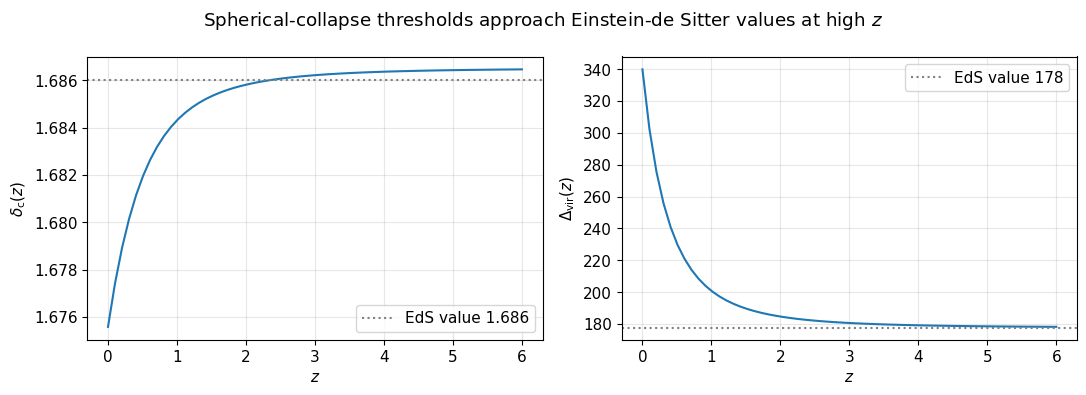

delta_c(z=0) = 1.6756,  Delta_vir(z=0) = 339.8


In [4]:
criticalOverdensity = galacticus.criticalOverdensitySphericalCollapseClsnlssMttrCsmlgclCnstnt(
    linearGrowth, cosmologyFunctions, cosmologicalMassVariance, darkMatterParticle, True)
virialDensityContrast = galacticus.virialDensityContrastSphericalCollapseClsnlssMttrCsmlgclCnstnt(
    True, cosmologyFunctions)

zGrid  = np.linspace(0.0, 6.0, 60)
deltaC = np.array([criticalOverdensity.value(time=timeOf(z), mass=1.0e12)   for z in zGrid])
DeltaV = np.array([virialDensityContrast.densityContrast(1.0e12, time=timeOf(z)) for z in zGrid])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(zGrid, deltaC); axes[0].axhline(1.686, color='gray', ls=':', label='EdS value 1.686')
axes[0].set_xlabel('$z$'); axes[0].set_ylabel('$\\delta_\\mathrm{c}(z)$'); axes[0].legend()
axes[1].plot(zGrid, DeltaV); axes[1].axhline(177.65, color='gray', ls=':', label='EdS value 178')
axes[1].set_xlabel('$z$'); axes[1].set_ylabel('$\\Delta_\\mathrm{vir}(z)$'); axes[1].legend()
fig.suptitle('Spherical-collapse thresholds approach Einstein-de Sitter values at high $z$')
fig.tight_layout(); plt.show()
print(f"delta_c(z=0) = {deltaC[0]:.4f},  Delta_vir(z=0) = {DeltaV[0]:.1f}")

## The mass function today: Sheth-Tormen vs. Tinker et al.

`differential(time, mass)` returns $\mathrm{d}n/\mathrm{d}M$ in units of
Mpc$^{-3} M_\odot^{-1}$; we plot $\mathrm{d}n/\mathrm{d}\ln M = M\,
\mathrm{d}n/\mathrm{d}M$. The two calibrations agree to tens of percent
over the well-resolved range — differences of exactly the size that matter
when you fit galaxy surveys.

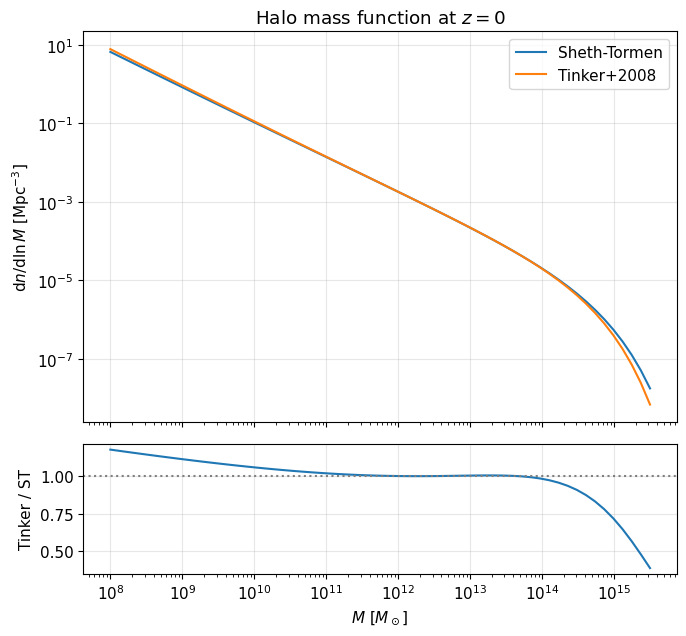

In [5]:
haloMassFunctionST = galacticus.haloMassFunctionShethTormen(
    cosmologyParameters, cosmologicalMassVariance, criticalOverdensity,
    0.707, 0.3, 0.322183)     # a, p, normalization (Sheth & Tormen 1999)
haloMassFunctionTinker = galacticus.haloMassFunctionTinker2008(
    cosmologyParameters, cosmologicalMassVariance, linearGrowth,
    cosmologyFunctions, virialDensityContrast)

masses = np.logspace(8, 15.5, 60)
fig, (axF, axR) = plt.subplots(2, 1, figsize=(7, 6.5), sharex=True,
                               gridspec_kw={'height_ratios': (3, 1)})
dndlnM = {}
for label, hmf in (('Sheth-Tormen', haloMassFunctionST), ('Tinker+2008', haloMassFunctionTinker)):
    dndlnM[label] = np.array([M*hmf.differential(ageToday, M) for M in masses])
    axF.loglog(masses, dndlnM[label], label=label)
axF.set_ylabel('$\\mathrm{d}n/\\mathrm{d}\\ln M$ [Mpc$^{-3}$]'); axF.legend()
axF.set_title('Halo mass function at $z=0$')
axR.semilogx(masses, dndlnM['Tinker+2008']/dndlnM['Sheth-Tormen'])
axR.axhline(1.0, color='gray', ls=':')
axR.set_xlabel('$M$ [$M_\\odot$]'); axR.set_ylabel('Tinker / ST')
fig.tight_layout(); plt.show()

## Evolution with redshift

The exponential high-mass cut-off tracks $\delta_\mathrm{c}/\sigma(M,t)$:
cluster-mass halos are exponentially rare at $z=4$, while the dwarf-scale
mass function barely moves.

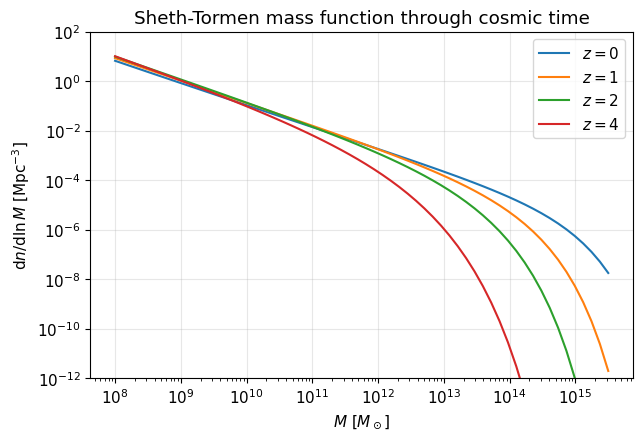

In [6]:
for z, color in ((0.0, 'C0'), (1.0, 'C1'), (2.0, 'C2'), (4.0, 'C3')):
    t = timeOf(z)
    plt.loglog(masses, [M*haloMassFunctionST.differential(t, M) for M in masses],
               color=color, label=f'$z={z:.0f}$')
plt.ylim(1.0e-12, 1.0e2)
plt.xlabel('$M$ [$M_\\odot$]'); plt.ylabel('$\\mathrm{d}n/\\mathrm{d}\\ln M$ [Mpc$^{-3}$]')
plt.legend(); plt.title('Sheth-Tormen mass function through cosmic time')
plt.show()

## How much matter lives in halos?

`massFraction(time, massLow, massHigh)` integrates the mass-weighted mass
function — the collapsed fraction. Watching it grow with cosmic time is
hierarchical structure formation in a single number.

  z = 6.0:  fraction of matter in halos above 1e8 Msun = 0.094
  z = 4.0:  fraction of matter in halos above 1e8 Msun = 0.190
  z = 3.0:  fraction of matter in halos above 1e8 Msun = 0.260
  z = 2.0:  fraction of matter in halos above 1e8 Msun = 0.348
  z = 1.0:  fraction of matter in halos above 1e8 Msun = 0.454
  z = 0.5:  fraction of matter in halos above 1e8 Msun = 0.512
  z = 0.0:  fraction of matter in halos above 1e8 Msun = 0.570


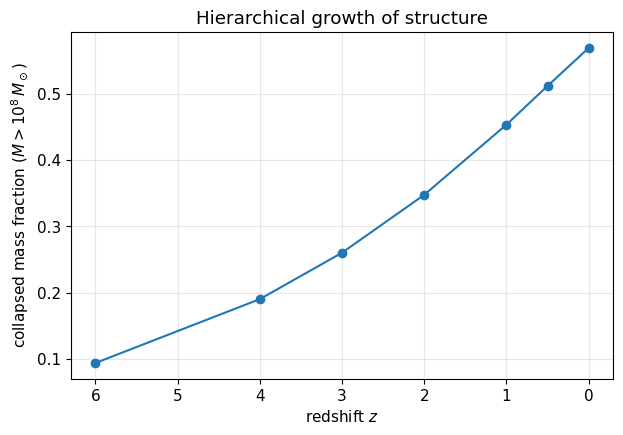

In [7]:
zGrid = np.array([6.0, 4.0, 3.0, 2.0, 1.0, 0.5, 0.0])
fractions = [haloMassFunctionST.massFraction(timeOf(z), 1.0e8, 1.0e16) for z in zGrid]
for z, f in zip(zGrid, fractions):
    print(f"  z = {z:3.1f}:  fraction of matter in halos above 1e8 Msun = {f:.3f}")
plt.plot(zGrid, fractions, 'o-')
plt.gca().invert_xaxis()
plt.xlabel('redshift $z$'); plt.ylabel('collapsed mass fraction ($M > 10^8\\,M_\\odot$)')
plt.title('Hierarchical growth of structure')
plt.show()

**Try it yourself:** swap the transfer function for one of the WDM variants
from Tutorial 2 and re-run — the low-mass slope of the mass function
flattens and turns over below the half-mode mass.